# **Mental Health Survey: What Factors May Cause Depression**

*   Sylvia Li
*   Aaron Huang

# Overview
Our goal is to analyze data from a mental health survey to explore the factors that may contribute to depression. We’re particularly interested in this topic because mental health is a critical aspect of overall well-being, especially for college students who often face unique pressures and challenges.

**A real-world question that we’d like to explore, and why it’s interesting:**

*   What are the key factors associated with an increased risk of depression?
*  Understanding what might lead to depression can help us identify areas where support and resources are needed most.




**A berief description of the dataset:**
*   Author name: Suman Sharma
*   URL: https://www.kaggle.com/datasets/sumansharmadataworld/depression-surveydataset-for-analysis/data
*   Data Overview: Collected anonymously in early 2023 from adults aged 18-60 across various cities, focusing on diverse demographic and lifestyle factors.
*   Key Variables: Includes age, gender, city, education, job/study, satisfaction, work hours, and family history.
*   Target Variable: 'Depression' ('Yes'/'No') indicates risk levels based on participant responses.

# Prior Work

**URL**: https://www.kaggle.com/code/orkunaran/predicting-depression-anxiety-and-stress-eda#Conclusion
>The project by Orkun Aran on Kaggle explores how to predicte depression, anxiety, and stress using survey data. It focuses on exploratory data analysis (EDA) and visualizations to highlight key features influencing mental health.
>
>**Response**:
*   Strengths: clear visualizations and effective feature selection
*   Improvements: More advanced machine learning models and external data could improve the model’s accuracy.
*   Trust: The results appears to be trustworthy
>
>This project could be expanded by testing advanced models or using additional data sources to improve predictive accuracy.

#Approach

- **Problem Description**
  - **What factors in the survey data contribute the most to predicting depression?**
  - This question focuses on finding patterns in the data to understand which factors are closely linked to depression. The goal is to identify the strongest predictors and use them to build a model that can help explain depression risks.

- **How We’ll Answer This Question**
  - Perform exploratory data analysis (EDA) to understand the distribution of variables and any initial patterns.
  - Use predictive modeling techniques such as logistic regression or decision trees to quantify the impact of each feature on the likelihood of depression.
  - Validate the results using appropriate performance metrics, like accuracy, precision, and recall, to assess the model's predictive power.

- **Data Provenance**
  - The dataset originates from a mental health survey conducted from January to June 2023. The survey was designed to explore depression risk factors among adults aged 18 to 60. It includes variables like age, gender, city, education, job satisfaction, work hours, and family history.
  - This dataset was downloaded from Kaggle, where it was made publicly available for analysis. The data was likely aggregated and anonymized by survey organizers before being uploaded to Kaggle for community use.

- **Data Overview**
  - Number of Records: The dataset contains 2556 rows, each representing a unique respondent's survey response.
  - The first row represents a female called Pooja from Ghaziabad, she is 37 years old, she is a working professional as a teacher with 2 level working pressure, her job satisfaction is level 4, sleeping duration is 7-8 hours, dietary habits is moderate, degree is MA, never had suicide thoughts before, working 6h daily, level 2 on financial stress level , no family history of mental illness, and no depression.

- **Features and Their Types:**
  1. Name: Name of the individual (string).
  2. Gender: Gender of the individual (string).
  3. Age: Age of the individual (float).
  4. City: City of residence (string).
  5. Working Professional or Student: Identifies if the individual is a working professional or a student (string).
  6. Profession: The profession of the individual, if applicable (string, 74% non-null).
  7. Academic Pressure: Self-reported level of academic pressure (float, 20% non-null).
  8. Work Pressure: Self-reported level of work pressure (float, 80% non-null).
  9. CGPA: Current Grade Point Average for students (float, 20% non-null).
  10. Study Satisfaction: Satisfaction with studies (float, 20% non-null).
  11. Job Satisfaction: Satisfaction with job (float, 80% non-null).
  12. Sleep Duration: Duration of sleep, typically represented as hours per night (string).
  13. Dietary Habits: Describes the individual's dietary habits (string).
  14. Degree: The degree held by the individual (string).
  15. Suicidal Thoughts: Indicates whether the individual has experienced suicidal thoughts (string).
  16. Work/Study Hours: Daily hours spent working or studying (float).
  17. Financial Stress: Self-reported level of financial stress (float).
  18. Family History of Mental Illness: Indicates if there is a family history of mental illness (string).
  19. Depression: Presence or absence of depression (int).

- **Dataset Appropriateness**
  - **Strengths:**
    - The dataset includes relevant features directly linked to potential risk factors for depression.
    - The large sample size (2556 respondents) allows for robust statistical analysis and modeling.
    - The temporal range (January–June 2023) ensures the data is relatively recent and reflective of current trends.
  - **Limitations:**
    - Self-reported data may introduce bias or inaccuracies in variables like job satisfaction or work hours.
    - Lack of additional contextual factors, such as socioeconomic status or physical health metrics, may limit the depth of analysis.








**Initial Steps**:
Perform EDA to identify meaningful variables correlated with "Depression Status." and remove irrelevant features. Ensure categorical variables are properly encoded and numerical data is scaled.

*   Remove "City of Residence" because it requires external information about the city to make it useful. With merely the name of the city, the core factors related to depression can never be determined.

*   Remove "Profession" for the same reason, as it requires salary, working environment, etc., to conclude any useful information.

**Handling Missing Values**: The missing value is cause by student having no data of job related, and non-student having no work-related data, thus divide the dataset into students and non-students to address missing values contextually:

>For students, focus on academic-related variables.
For non-students, emphasize work-related variables.
Impute critical missing values using subgroup-specific means, medians, or predictive methods, but avoid unnecessary imputation.

**Feature Selection and Transformation**:
Retain variables strongly correlated with the target (e.g., "Work Pressure," "Academic Pressure") and discard weakly correlated ones. Use dummy variables for categories and standardize numerical features for consistency.


# Data Wrangling

In [ ]:
# orginal data set
import pandas as pd
import plotly.express as px

df = pd.read_csv("final_depression_dataset_1.csv")

df.head()

,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Pooja,Female,37,Ghaziabad,Working Professional,Teacher,NaN,2.0,NaN,NaN,4.0,7-8 hours,Moderate,MA,No,6,2,No,No
1,Reyansh,Male,60,Kalyan,Working Professional,Financial Analyst,NaN,4.0,NaN,NaN,3.0,5-6 hours,Unhealthy,B.Com,Yes,0,4,Yes,No
2,Manvi,Female,42,Bhopal,Working Professional,Teacher,NaN,2.0,NaN,NaN,3.0,5-6 hours,Moderate,M.Com,No,0,2,No,No
3,Isha,Female,44,Thane,Working Professional,Teacher,NaN,3.0,NaN,NaN,5.0,7-8 hours,Healthy,MD,Yes,1,2,Yes,No
4,Aarav,Male,48,Indore,Working Professional,UX/UI Designer,NaN,4.0,NaN,NaN,3.0,7-8 hours,Moderate,BE,Yes,6,5,Yes,No


In [ ]:
import pandas as pd
import plotly.express as px

# Load the dataset
df = pd.read_csv("final_depression_dataset_1.csv")

# Replace the column
df['Student or Not'] = df['Working Professional or Student'].apply(lambda x: "Yes" if x == "Student" else "No")

# Drop the original column if no longer needed
df = df.drop(columns=['Working Professional or Student','City'])

# Insert 'Student or Not' column right after 'Age'
columns = list(df.columns)
age_index = columns.index("Age")
columns.insert(age_index + 1, columns.pop(columns.index("Student or Not")))

# Reorder the DataFrame columns
df = df[columns]

# Display the updated DataFrame
df.head()


,Name,Gender,Age,Student or Not,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Pooja,Female,37,No,Teacher,NaN,2.0,NaN,NaN,4.0,7-8 hours,Moderate,MA,No,6,2,No,No
1,Reyansh,Male,60,No,Financial Analyst,NaN,4.0,NaN,NaN,3.0,5-6 hours,Unhealthy,B.Com,Yes,0,4,Yes,No
2,Manvi,Female,42,No,Teacher,NaN,2.0,NaN,NaN,3.0,5-6 hours,Moderate,M.Com,No,0,2,No,No
3,Isha,Female,44,No,Teacher,NaN,3.0,NaN,NaN,5.0,7-8 hours,Healthy,MD,Yes,1,2,Yes,No
4,Aarav,Male,48,No,UX/UI Designer,NaN,4.0,NaN,NaN,3.0,7-8 hours,Moderate,BE,Yes,6,5,Yes,No


In [ ]:
# Filter the dataset to include only rows where "Student or Not" is "Yes"
df_students = df[df["Student or Not"] == "Yes"]

# Drop the irrelevant and empty columns
columns_to_exclude = [ 'Work Pressure', 'Job Satisfaction','Profession']
df_students_filtered = df_students.drop(columns=columns_to_exclude)

# Display the filtered dataset
df_students_filtered.head()

,Name,Gender,Age,Student or Not,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
17,Advait,Male,28,Yes,2.0,6.51,4.0,7-8 hours,Moderate,BA,Yes,9,2,Yes,No
19,Sanket,Male,28,Yes,4.0,7.48,5.0,5-6 hours,Healthy,MD,Yes,7,1,Yes,No
28,Ranveer,Male,25,Yes,1.0,7.21,3.0,5-6 hours,Unhealthy,MBBS,Yes,10,4,No,Yes
33,Gagan,Male,23,Yes,1.0,9.90,4.0,More than 8 hours,Unhealthy,MSc,Yes,7,2,Yes,No
35,Tina,Female,31,Yes,1.0,5.97,5.0,More than 8 hours,Healthy,LLM,Yes,4,2,Yes,No


In [ ]:
# Filter the dataset to exclude rows where "Working Professional or Student" is "Student"
df_not_students = df[df["Student or Not"] != "Yes"]

# Drop the irrelevant and empty columns
excluded_columns = ['Academic Pressure', 'CGPA', 'Study Satisfaction']
df_not_students_filtered = df_not_students.drop(columns=excluded_columns)

# Display the filtered dataset
df_not_students_filtered.head()

,Name,Gender,Age,Student or Not,Profession,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Pooja,Female,37,No,Teacher,2.0,4.0,7-8 hours,Moderate,MA,No,6,2,No,No
1,Reyansh,Male,60,No,Financial Analyst,4.0,3.0,5-6 hours,Unhealthy,B.Com,Yes,0,4,Yes,No
2,Manvi,Female,42,No,Teacher,2.0,3.0,5-6 hours,Moderate,M.Com,No,0,2,No,No
3,Isha,Female,44,No,Teacher,3.0,5.0,7-8 hours,Healthy,MD,Yes,1,2,Yes,No
4,Aarav,Male,48,No,UX/UI Designer,4.0,3.0,7-8 hours,Moderate,BE,Yes,6,5,Yes,No


Thus, all empty spaces are removed. However, since the dataset is well-structured, the only empty spaces occur for logical reasons, such as students having no job, resulting in work pressure being empty. These empty spaces ultimately would not impact the modeling or analysis.

#Exploratory Data Analysis (EDA)

This section explores the key factors contributing to depression through visual analysis of survey data. By examining relationships across variables, we aim to identify significant patterns and trends that may impact mental health outcomes.

In [ ]:
# Change the name for the two filter data set to something shorter to make the rest step easier.

df_students_filtered['Depression Status'] = df_students_filtered['Depression'].apply(lambda x: 'Depression' if x == 'Yes' else 'No Depression')
student = df_students_filtered  # Assign the df_students_filtered with student

df_not_students_filtered['Depression Status'] = df_not_students_filtered['Depression'].apply(lambda x: 'Depression' if x == 'Yes' else 'No Depression')
not_student = df_not_students_filtered  # Assign the df_not_students_filtered with not_student

###Work Pressure, Job Satisfaction, Academic Pressure, Study Satisfaction

We begin by exploring the relationship between work pressure and job satisfaction, followed by an analysis of how academic pressure and study satisfaction influence depression, especially among students.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create a 2x2 subplot grid
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Work Pressure vs Depression',
        'Job Satisfaction vs Depression',
        'Academic Pressure vs Depression',
        'Study Satisfaction vs Depression'
    ),
    shared_yaxes=True
)

# Define colors for Depression Status
colors = {'Depression': 'orange', 'No Depression': 'lightblue'}

# Function to add traces with ratios
def add_bar_with_ratios(grouped_data, x_col, title, row, col):
    # Calculate total count per category (e.g., Work Pressure)
    totals = grouped_data.groupby(x_col)['Count'].sum().reset_index(name='Total')
    # Merge totals into the grouped data
    grouped_data = grouped_data.merge(totals, on=x_col)
    # Calculate the ratio for each bar
    grouped_data['Ratio'] = grouped_data['Count'] / grouped_data['Total']

    for status in colors:
        filtered_data = grouped_data[grouped_data['Depression Status'] == status]
        fig.add_trace(
            go.Bar(
                x=filtered_data[x_col],
                y=filtered_data['Count'],
                name=status,  # Single legend entry for each status
                legendgroup=status,  # Group traces with the same status together
                marker_color=colors[status],
                text=(filtered_data['Ratio'] * 100).round(2).astype(str) + '%',  # Add percentages
                textposition='auto',  # Position text inside bars
                showlegend=(row == 1 and col == 1)  # Show legend only in the first subplot
            ),
            row=row, col=col
        )


# Grouped data for each plot
grouped_work_pressure = not_student.groupby(['Work Pressure', 'Depression Status']).size().reset_index(name='Count')
grouped_job_satisfaction = not_student.groupby(['Job Satisfaction', 'Depression Status']).size().reset_index(name='Count')
grouped_academic_pressure = student.groupby(['Academic Pressure', 'Depression Status']).size().reset_index(name='Count')
grouped_study_satisfaction = student.groupby(['Study Satisfaction', 'Depression Status']).size().reset_index(name='Count')

# Add subplots with calculated ratios
add_bar_with_ratios(grouped_work_pressure, 'Work Pressure', 'Work Pressure vs Depression', 1, 1)
add_bar_with_ratios(grouped_job_satisfaction, 'Job Satisfaction', 'Job Satisfaction vs Depression', 1, 2)
add_bar_with_ratios(grouped_academic_pressure, 'Academic Pressure', 'Academic Pressure vs Depression', 2, 1)
add_bar_with_ratios(grouped_study_satisfaction, 'Study Satisfaction', 'Study Satisfaction vs Depression', 2, 2)



# Update layout with legend, titles, and axis labels
fig.update_layout(
    title_text="Factors Contributing to Depression Status with Ratios",
    barmode='group',  # Bars grouped side by side
    height=800,
    width=1000,
    legend_title="Depression Status"
)

fig.show()


**Findings**:

For None Student:
>Though depression levels remain low for both levels of work pressure and job satisfaction, there is still a clear trend: as the level of work pressure increases, the rate of depression increases as well. Conversely, for job satisfaction, higher levels correlate with lower rates of depression.


For Student:
>Unlike non-students, the rate of depression across all levels is higher for students. There is a clear trend that as academic pressure increases, the rate of depression also increases. Conversely, higher levels of academic satisfaction correlate with lower rates of depression

###Family History and Depression Status

After exploring the roles of work, academic, and personal satisfaction factors, we now turn to examine whether a family history of mental illness plays a role in depression.

In [ ]:
# Group the data by Family History and Depression Status
grouped_data1 = student.groupby(['Family History of Mental Illness', 'Depression Status']).size().reset_index(name='Count')
grouped_data2 = not_student.groupby(['Family History of Mental Illness', 'Depression Status']).size().reset_index(name='Count')

# Create a 1x2 subplot grid
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Student: Family History and Depression', 'Non-Student: Family History and Depression'),
    shared_yaxes=True
)

# Function to add traces with grouped legend entries
def add_bar_grouped_legend(data, row, col):
    for status, color in {'Depression': 'orange', 'No Depression': 'lightblue'}.items():
        filtered_data = data[data['Depression Status'] == status]
        fig.add_trace(
            go.Bar(
                x=filtered_data['Family History of Mental Illness'],
                y=filtered_data['Count'],
                name=status,  # Use the status directly for legend grouping
                legendgroup=status,  # Group traces with the same status
                marker_color=color,
                showlegend=(row == 1 and col == 1)  # Show legend only for the first plot
            ),
            row=row, col=col
        )

# Add traces for both student and non-student data
add_bar_grouped_legend(grouped_data1, row=1, col=1)
add_bar_grouped_legend(grouped_data2, row=1, col=2)

# Update layout with titles and axis labels
fig.update_layout(
    title_text="Comparison of Family History and Depression Status",
    barmode='group',  # Bars grouped side by side
    height=600,
    width=1000,
    legend_title="Depression Status",
    xaxis=dict(
        title="Family History of Mental Illness",  # Clear label for x-axis
        tickvals=['No', 'Yes'],  # Explicitly define tick values
        ticktext=['No Family History', 'Has Family History']  # Clearer labels
    ),
    xaxis2=dict(  # For the second plot
        title="Family History of Mental Illness",
        tickvals=['No', 'Yes'],
        ticktext=['No Family History', 'Has Family History']
    )
)

fig.show()


**Findings:** This plot demonstrates a clear trend that students have a significantly higher proportion of depression compared to non-students. While there is a slight tendency for individuals with a family history of mental illness to exhibit slightly higher rates of depression, the difference is not substantial enough to consider family history a strong contributing factor. Thus, for the modeling, **family history is not included as a feature**, given that its impact on depression is not significant enough to justify its inclusion.

###Suicidal Thoughts

From family history, we turn our focus to suicidal thoughts, examining their strong association with depression across different groups.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Group the data by Suicidal Thoughts and Depression Status for Student and Non-Student
grouped_data1 = student.groupby(['Have you ever had suicidal thoughts ?', 'Depression Status']).size().reset_index(name='Count')
grouped_data2 = not_student.groupby(['Have you ever had suicidal thoughts ?', 'Depression Status']).size().reset_index(name='Count')

# Create a 1x2 subplot grid
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Student: Suicidal Thoughts', 'Non-Student: Suicidal Thoughts'),
    shared_yaxes=True
)

# Function to add bars with ratio annotations and grouped legend
def add_bar_with_grouped_legend(grouped_data, x_col, row, col):
    # Calculate total count per category (e.g., Suicidal Thoughts)
    totals = grouped_data.groupby(x_col)['Count'].sum().reset_index(name='Total')
    grouped_data = grouped_data.merge(totals, on=x_col)
    # Calculate the ratio for each bar
    grouped_data['Ratio'] = grouped_data['Count'] / grouped_data['Total']

    for status, color in {'Depression': 'orange', 'No Depression': 'lightblue'}.items():
        filtered_data = grouped_data[grouped_data['Depression Status'] == status]
        fig.add_trace(
            go.Bar(
                x=filtered_data[x_col],
                y=filtered_data['Count'],
                name=status,  # Use the same name for legend grouping
                legendgroup=status,  # Group traces with the same legend name
                marker_color=color,
                text=(filtered_data['Ratio'] * 100).round(2).astype(str) + '%',  # Add percentage annotations
                textposition='auto',  # Position text inside bars
                showlegend=(row == 1 and col == 1)  # Show legend only for the first subplot
            ),
            row=row, col=col
        )

# Add traces for student and non-student data
add_bar_with_grouped_legend(grouped_data1, 'Have you ever had suicidal thoughts ?', 1, 1)
add_bar_with_grouped_legend(grouped_data2, 'Have you ever had suicidal thoughts ?', 1, 2)

# Update layout with titles and axis labels
fig.update_layout(
    title_text="Comparison of Suicidal Thoughts and Depression Status with Ratios",
    barmode='group',  # Bars grouped side by side
    height=600,
    width=1000,
    legend_title="Depression Status",
    xaxis=dict(
        title="Suicidal Thoughts",  # Clear x-axis label
        tickvals=['No', 'Yes'],  # Explicitly set tick values
        ticktext=['No Suicidal Thoughts', 'Has Suicidal Thoughts']  # Clarify labels
    ),
    xaxis2=dict(  # For the second subplot
        title="Suicidal Thoughts",
        tickvals=['No', 'Yes'],
        ticktext=['No Suicidal Thoughts', 'Has Suicidal Thoughts']
    )
)

fig.show()


**Findings**: Those with suicidal thoughts, regardless of whether they are students or not, show a strong tendency to have depression. This suggests that suicidal thoughts are closely associated with depression, and this relationship should be considered in the modeling process.

###Age vs Depression by Gender

Next, we explore how demographic factors such as age and gender impact depression rates, adding a broader perspective to our analysis.

In [ ]:
grouped_work_pressure = student.groupby(['Age', 'Gender', 'Depression Status']).size().reset_index(name='Count')
fig1 = go.Figure()

# Define colors for each category
colors = {
    ('Male', 'Depression'): 'orange',
    ('Male', 'No Depression'): 'lightblue',
    ('Female', 'Depression'): 'lightsalmon',
    ('Female', 'No Depression'): 'cadetblue'
}

# Add traces for each gender and depression status
for (gender, status), color in colors.items():
    filtered_data = grouped_work_pressure[
        (grouped_work_pressure['Gender'] == gender) &
        (grouped_work_pressure['Depression Status'] == status)
    ]
    fig1.add_trace(
        go.Bar(
            x=filtered_data['Age'],
            y=filtered_data['Count'],
            name=f"{gender} - {status}",  # Label combines Gender and Depression Status
            marker_color=color
        )
    )

fig1.update_layout(
    title="Age vs Depression by Gender for Student",
    xaxis_title="Age",
    yaxis_title="Count",
    barmode='group',  # Group bars side-by-side
    legend_title="Gender and Depression Status"
)
fig1.show()

In [ ]:
grouped_work_pressure = not_student.groupby(['Age', 'Gender', 'Depression Status']).size().reset_index(name='Count')
fig1 = go.Figure()

# Define colors for each category
colors = {
    ('Male', 'Depression'): 'orange',
    ('Male', 'No Depression'): 'lightblue',
    ('Female', 'Depression'): 'lightsalmon',
    ('Female', 'No Depression'): 'cadetblue'
}

# Add traces for each gender and depression status
for (gender, status), color in colors.items():
    filtered_data = grouped_work_pressure[
        (grouped_work_pressure['Gender'] == gender) &
        (grouped_work_pressure['Depression Status'] == status)
    ]
    fig1.add_trace(
        go.Bar(
            x=filtered_data['Age'],
            y=filtered_data['Count'],
            name=f"{gender} - {status}",  # Label combines Gender and Depression Status
            marker_color=color
        )
    )

fig1.update_layout(
    title="Age vs Depression by Gender for None Student",
    xaxis_title="Age",
    yaxis_title="Count",
    barmode='group',  # Group bars side-by-side
    legend_title="Gender and Depression Status"
)
fig1.show()

**Findings**: For both dataset, Steudent and Not_Student, While some information can be extracted from two plots, it is difficult to see any clear trend. It is necessary to explore alternative methods to analyze these data sets


In [ ]:
import plotly.graph_objects as go

# Group the data by Age, Gender, and Depression Status
grouped_work_pressure = not_student.groupby(['Age', 'Gender', 'Depression Status']).size().reset_index(name='Count')

# Calculate the total count of Depression and No Depression for each Age and Gender
total_counts = grouped_work_pressure.groupby(['Age', 'Gender'])['Count'].sum().reset_index(name='Total')

# Merge the total counts with the grouped data to calculate the ratio
grouped_work_pressure = grouped_work_pressure.merge(total_counts, on=['Age', 'Gender'])

# Calculate the ratio for Depression and No Depression
grouped_work_pressure['Depression_Ratio'] = grouped_work_pressure.apply(
    lambda row: row['Count'] / row['Total'] if row['Depression Status'] == 'Depression' else 0, axis=1)
grouped_work_pressure['No_Depression_Ratio'] = grouped_work_pressure.apply(
    lambda row: row['Count'] / row['Total'] if row['Depression Status'] == 'No Depression' else 0, axis=1)

# Create a figure for the line plot
fig1 = go.Figure()

# Add line traces for Depression and No Depression
for gender in ['Male', 'Female']:
    for status, color in [
        ('Depression', 'orange' if gender == 'Male' else 'lightsalmon'),
        ('No Depression', 'lightblue' if gender == 'Male' else 'cadetblue')
    ]:
        filtered_data = grouped_work_pressure[
            (grouped_work_pressure['Gender'] == gender) &
            (grouped_work_pressure['Depression Status'] == status)
        ]
        if status == 'Depression':
            fig1.add_trace(
                go.Scatter(
                    x=filtered_data['Age'],
                    y=filtered_data['Depression_Ratio'],
                    mode='lines+markers',
                    name=f"{gender} - {status}",
                    line=dict(color=color)
                )
            )
        else:
            fig1.add_trace(
                go.Scatter(
                    x=filtered_data['Age'],
                    y=filtered_data['No_Depression_Ratio'],
                    mode='lines+markers',
                    name=f"{gender} - {status}",
                    line=dict(color=color)
                )
            )

fig1.update_layout(
    title="Age vs Depression by Gender for None Student",
    xaxis_title="Age",
    yaxis_title="Ratio (0 to 1)",
    legend_title="Gender and Depression Status",
    yaxis=dict(range=[0, 1])  # Ensure the y-axis range is from 0 to 1
)

fig1.show()


**Now there is a clear trend!!!**

**Note**: For non-students, gender does not appear to significantly impact depression levels, as the ratios of having depression to not having depression are relatively consistent between males and females. However, age shows a clear trend: as age increases, the ratio of depression steadily decreases. This suggests that older individuals in the non-student group are less likely to experience depression compared to younger individuals.

In [ ]:
import plotly.graph_objects as go

# Group the data by Age, Gender, and Depression Status
grouped_work_pressure = student.groupby(['Age', 'Gender', 'Depression Status']).size().reset_index(name='Count')

# Calculate the total count of Depression and No Depression for each Age and Gender
total_counts = grouped_work_pressure.groupby(['Age', 'Gender'])['Count'].sum().reset_index(name='Total')

# Merge the total counts with the grouped data to calculate the ratio
grouped_work_pressure = grouped_work_pressure.merge(total_counts, on=['Age', 'Gender'])

# Calculate the ratio for Depression and No Depression
grouped_work_pressure['Depression_Ratio'] = grouped_work_pressure.apply(
    lambda row: row['Count'] / row['Total'] if row['Depression Status'] == 'Depression' else 0, axis=1)
grouped_work_pressure['No_Depression_Ratio'] = grouped_work_pressure.apply(
    lambda row: row['Count'] / row['Total'] if row['Depression Status'] == 'No Depression' else 0, axis=1)

# Create a figure for the line plot
fig1 = go.Figure()

# Add line traces for Depression and No Depression
for gender in ['Male', 'Female']:
    for status, color in [
        ('Depression', 'orange' if gender == 'Male' else 'lightsalmon'),
        ('No Depression', 'lightblue' if gender == 'Male' else 'cadetblue')
    ]:
        filtered_data = grouped_work_pressure[
            (grouped_work_pressure['Gender'] == gender) &
            (grouped_work_pressure['Depression Status'] == status)
        ]
        if status == 'Depression':
            fig1.add_trace(
                go.Scatter(
                    x=filtered_data['Age'],
                    y=filtered_data['Depression_Ratio'],
                    mode='lines+markers',
                    name=f"{gender} - {status}",
                    line=dict(color=color)
                )
            )
        else:
            fig1.add_trace(
                go.Scatter(
                    x=filtered_data['Age'],
                    y=filtered_data['No_Depression_Ratio'],
                    mode='lines+markers',
                    name=f"{gender} - {status}",
                    line=dict(color=color)
                )
            )

fig1.update_layout(
    title="Age vs Depression by Gender for Student",
    xaxis_title="Age",
    yaxis_title="Ratio (0 to 1)",
    legend_title="Gender and Depression Status",
    yaxis=dict(range=[0, 1])  # Ensure the y-axis range is from 0 to 1
)

fig1.show()


**Findings**: Male depression rates fluctuate significantly across age groups, suggesting age-specific factors influence male students' depression. In contrast, male no-depression rates remain stable. Female depression shows sharp peaks and drops, indicating potential age-specific stressors, while female no-depression rates are relatively consistent with less variation.

**Comparasion of Two Plot**

Similar to non-students, gender seems to make little difference. However, there appears to be a trend where, as age increases, the ratio of depression slightly decreases, which is similar to non-students. Age does, however, appear to be less impactful to student compared to non-students.

###Financial Stress vs Depression

Building on the demographic analysis, we now examine how financial stress influences depression, shedding light on the impact of economic pressures on mental health.

In [ ]:
import plotly.graph_objects as go

# Group the data by Financial Stress and Depression Status
grouped_Financial_pressure = student.groupby(['Financial Stress', 'Depression Status']).size().reset_index(name='Count')

# Calculate the total count for each level of Financial Stress
total_counts = grouped_Financial_pressure.groupby('Financial Stress')['Count'].sum().reset_index(name='Total')

# Merge the total counts back into the grouped data
grouped_Financial_pressure = grouped_Financial_pressure.merge(total_counts, on='Financial Stress')

# Calculate the ratio for each bar
grouped_Financial_pressure['Ratio'] = grouped_Financial_pressure['Count'] / grouped_Financial_pressure['Total']

# Create the bar plot
fig1 = go.Figure()

# Add traces for each Depression Status
colors = {'Depression': 'orange', 'No Depression': 'lightblue'}
for status, color in colors.items():
    filtered_data = grouped_Financial_pressure[grouped_Financial_pressure['Depression Status'] == status]
    fig1.add_trace(
        go.Bar(
            x=filtered_data['Financial Stress'],
            y=filtered_data['Count'],
            name=status,  # Add label
            marker_color=color,
            text=(filtered_data['Ratio'] * 100).round(2).astype(str) + '%',  # Add percentage text
            textposition='auto'  # Position text inside bars
        )
    )

# Update layout
fig1.update_layout(
    title="Financial Stress vs Depression with Ratios for Student",
    xaxis_title="Financial Stress",
    yaxis_title="Count",
    barmode='group',  # Group bars side-by-side
    legend_title="Depression Status"
)

# Show the plot
fig1.show()

import plotly.graph_objects as go

# Group the data by Financial Stress and Depression Status
grouped_Financial_pressure = not_student.groupby(['Financial Stress', 'Depression Status']).size().reset_index(name='Count')

# Calculate the total count for each level of Financial Stress
total_counts = grouped_Financial_pressure.groupby('Financial Stress')['Count'].sum().reset_index(name='Total')

# Merge the total counts back into the grouped data
grouped_Financial_pressure = grouped_Financial_pressure.merge(total_counts, on='Financial Stress')

# Calculate the ratio for each bar
grouped_Financial_pressure['Ratio'] = grouped_Financial_pressure['Count'] / grouped_Financial_pressure['Total']

# Create the bar plot
fig1 = go.Figure()

# Add traces for each Depression Status
colors = {'Depression': 'orange', 'No Depression': 'lightblue'}
for status, color in colors.items():
    filtered_data = grouped_Financial_pressure[grouped_Financial_pressure['Depression Status'] == status]
    fig1.add_trace(
        go.Bar(
            x=filtered_data['Financial Stress'],
            y=filtered_data['Count'],
            name=status,  # Add label
            marker_color=color,
            text=(filtered_data['Ratio'] * 100).round(2).astype(str) + '%',  # Add percentage text
            textposition='auto'  # Position text inside bars
        )
    )

# Update layout
fig1.update_layout(
    title="Financial Stress vs Depression with Ratios for None Studnet",
    xaxis_title="Financial Stress",
    yaxis_title="Count",
    barmode='group',  # Group bars side-by-side
    legend_title="Depression Status"
)

# Show the plot
fig1.show()



**Findings**: Among students, higher levels of financial stress correspond to increased rates of depression. While a similar trend is observed for non-students, the overall depression rates at all levels of financial stress are significantly lower compared to students.

**Comparasion of Two Plot**

Students are more affected by financial stress than non-students. As financial stress increases, student depression rates rise sharply to 70.83%, while non-students maintain lower depression rates, peaking at 18.52%. This highlights students' higher vulnerability to financial challenges compared to non-students' resilience.



###Work/Study Hours and Depression Status

From financial stress, we shift to examining how daily work or study hours correlate with depression levels.

In [ ]:
import plotly.graph_objects as go

# student data
grouped_work_pressure_student = student.groupby(['Work/Study Hours', 'Depression Status']).size().reset_index(name='Count')
total_counts_student = grouped_work_pressure_student.groupby(['Work/Study Hours'])['Count'].sum().reset_index(name='Total')
grouped_work_pressure_student = grouped_work_pressure_student.merge(total_counts_student, on=['Work/Study Hours'])
grouped_work_pressure_student['Depression_Ratio'] = grouped_work_pressure_student.apply(
    lambda row: row['Count'] / row['Total'] if row['Depression Status'] == 'Depression' else 0, axis=1)
grouped_work_pressure_student['No_Depression_Ratio'] = grouped_work_pressure_student.apply(
    lambda row: row['Count'] / row['Total'] if row['Depression Status'] == 'No Depression' else 0, axis=1)

# non-student data
grouped_work_pressure_not_student = not_student.groupby(['Work/Study Hours', 'Depression Status']).size().reset_index(name='Count')
total_counts_not_student = grouped_work_pressure_not_student.groupby(['Work/Study Hours'])['Count'].sum().reset_index(name='Total')
grouped_work_pressure_not_student = grouped_work_pressure_not_student.merge(total_counts_not_student, on=['Work/Study Hours'])
grouped_work_pressure_not_student['Depression_Ratio'] = grouped_work_pressure_not_student.apply(
    lambda row: row['Count'] / row['Total'] if row['Depression Status'] == 'Depression' else 0, axis=1)
grouped_work_pressure_not_student['No_Depression_Ratio'] = grouped_work_pressure_not_student.apply(
    lambda row: row['Count'] / row['Total'] if row['Depression Status'] == 'No Depression' else 0, axis=1)

fig = go.Figure()

# Add line traces for student data (distinguishing between depression and no depression), and set colors and legend labels for students
for status, color in [('Depression', 'orange'), ('No Depression', 'lightblue')]:
    filtered_data_student = grouped_work_pressure_student[grouped_work_pressure_student['Depression Status'] == status]
    if status == 'Depression':
        fig.add_trace(
            go.Scatter(
                x=filtered_data_student['Work/Study Hours'],
                y=filtered_data_student['Depression_Ratio'] * 100,
                mode='lines+markers',
                name=f"Student - {status}",  # Indicate student group in the legend
                line=dict(color=color)
            )
        )
    else:
        fig.add_trace(
            go.Scatter(
                x=filtered_data_student['Work/Study Hours'],
                y=filtered_data_student['No_Depression_Ratio'] * 100,
                mode='lines+markers',
                name=f"Student - {status}",
                line=dict(color=color)
            )
        )

# Add line traces for non-student data (distinguishing between depression and no depression), and set different colors and legend labels for non-students
for status, color in [('Depression', 'lightsalmon'), ('No Depression', 'cadetblue')]:
    filtered_data_not_student = grouped_work_pressure_not_student[grouped_work_pressure_not_student['Depression Status'] == status]
    if status == 'Depression':
        fig.add_trace(
            go.Scatter(
                x=filtered_data_not_student['Work/Study Hours'],
                y=filtered_data_not_student['Depression_Ratio'] * 100,
                mode='lines+markers',
                name=f"Non-Student - {status}",  # Indicate non-student group in the legend
                line=dict(color=color)
            )
        )
    else:
        fig.add_trace(
            go.Scatter(
                x=filtered_data_not_student['Work/Study Hours'],
                y=filtered_data_not_student['No_Depression_Ratio'] * 100,
                mode='lines+markers',
                name=f"Non-Student - {status}",
                line=dict(color=color)
            )
        )

fig.update_layout(
    title="Work/Study Hours vs Depression For Student and Non-Student",
    xaxis_title="Work/Study Hours",
    yaxis_title="Percentage (%)",
    legend_title="Group and Depression Status",
    yaxis=dict(range=[0, 100])
)

fig.show()

**For students**, depression rates increase with longer work/study hours, stabilizing at around 40%, while no depression rates slightly decline, suggesting prolonged hours may elevate depression risk.

**For non-students**, depression rates remain minimal, under 10%, with no significant impact from work/study hours, while no depression rates stay consistently high at 90% or above.

**Findings**: Students show higher depression rates with increased work/study hours, while non-students maintain low depression levels regardless of workload. This suggests workload impacts students' mental health more than non-students.

###CGPA and Depression Status ###





For students, we further delve into academic performance and pressure, examining how CGPA and perceived academic demands relate to depression.

In [ ]:
import plotly.graph_objects as go

# Group the data by CGPA and Depression Status
grouped_CGPA = student.groupby(['CGPA', 'Depression Status']).size().reset_index(name='Count')

# Calculate the total count of Depression and No Depression for each CGPA
total_counts = grouped_CGPA.groupby(['CGPA'])['Count'].sum().reset_index(name='Total')

# Merge the total counts with the grouped data to calculate the ratio
grouped_CGPA = grouped_CGPA.merge(total_counts, on=['CGPA'])

# Calculate the ratio for Depression and No Depression
grouped_CGPA['Depression_Ratio'] = grouped_CGPA.apply(
    lambda row: row['Count'] / row['Total'] if row['Depression Status'] == 'Depression' else 0, axis=1)
grouped_CGPA['No_Depression_Ratio'] = grouped_CGPA.apply(
    lambda row: row['Count'] / row['Total'] if row['Depression Status'] == 'No Depression' else 0, axis=1)

# Create a figure for the dot plot
fig1 = go.Figure()

# Add dot traces for Depression and No Depression
for status, color in [('Depression', 'orange'), ('No Depression', 'lightblue')]:
    # Filter data for each status (Depression/No Depression)
    filtered_data = grouped_CGPA[grouped_CGPA['Depression Status'] == status]

    # Add trace for the selected status (Depression or No Depression)
    if status == 'Depression':
        fig1.add_trace(
            go.Scatter(
                x=filtered_data['CGPA'],
                y=filtered_data['Depression_Ratio'] * 100,  # Convert to percentage
                mode='markers',  # Use only markers (dots)
                name=f"{status}",
                marker=dict(color=color, size=8)  # Set marker size and color
            )
        )
    else:
        fig1.add_trace(
            go.Scatter(
                x=filtered_data['CGPA'],
                y=filtered_data['No_Depression_Ratio'] * 100,  # Convert to percentage
                mode='markers',  # Use only markers (dots)
                name=f"{status}",
                marker=dict(color=color, size=8)  # Set marker size and color
            )
        )

fig1.update_layout(
    title="CGPA vs Depression",
    xaxis_title="CGPA",
    yaxis_title="Percentage (%)",
    legend_title="Depression Status",
    yaxis=dict(range=[0, 100])  # Set the y-axis range from 0 to 100%
)

fig1.show()


**Findings**: The scatter plot shows that CGPA does not exhibit a strong correlation with depression status. Students with both high and low CGPA are distributed across depression and no-depression categories, suggesting that academic performance is not a significant standalone predictor of depression in this dataset.

###Sleep Duration and Depression Status

Turning to lifestyle habits, we explore the connection between sleep duration and depression to understand how rest impacts mental health.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# Group student data by Sleep Duration and Depression Status, and count occurrences
grouped_data1 = student.groupby(['Sleep Duration', 'Depression Status']).size().reset_index(name='Count')
# Group non-student data by Sleep Duration and Depression Status, and count occurrences
grouped_data2 = not_student.groupby(['Sleep Duration', 'Depression Status']).size().reset_index(name='Count')

# Define a sorting function to adjust the order of the Sleep Duration column
def sort_sleep_duration(x):
    order = {
        "Less than 5 hours": 0,
        "5-6 hours": 1,
        "6-7 hours": 2,
        "7-8 hours": 3
    }
    return order.get(x, len(order))

# Apply the sorting function to the Sleep Duration column in the student data
sorted_indices_student = grouped_data1['Sleep Duration'].apply(sort_sleep_duration).sort_values().index
grouped_data1['Sleep Duration'] = grouped_data1.loc[sorted_indices_student, 'Sleep Duration'].reset_index(drop=True)
grouped_data1['Count'] = grouped_data1.loc[sorted_indices_student, 'Count'].reset_index(drop=True)

# Apply the sorting function to the Sleep Duration column in the non-student data
sorted_indices_not_student = grouped_data2['Sleep Duration'].apply(sort_sleep_duration).sort_values().index
grouped_data2['Sleep Duration'] = grouped_data2.loc[sorted_indices_not_student, 'Sleep Duration'].reset_index(drop=True)
grouped_data2['Count'] = grouped_data2.loc[sorted_indices_not_student, 'Count'].reset_index(drop=True)

# Create a 1x2 subplot grid
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Student: Sleep Duration', 'None Student: Sleep Duration'),
    shared_yaxes=True
)

# Add traces for student data
for status, color in {'Depression': 'orange', 'No Depression': 'lightblue'}.items():
    filtered_data = grouped_data1[grouped_data1['Depression Status'] == status]
    fig.add_trace(
        go.Bar(
            x=filtered_data['Sleep Duration'],
            y=filtered_data['Count'],
            marker_color=color,
            name=status,  # Single legend entry for each status
            legendgroup=status,  # Group legend by Depression Status
            showlegend=True  # Show legend for the first subplot
        ),
        row=1, col=1
    )

# Add traces for non-student data
for status, color in {'Depression': 'orange', 'No Depression': 'lightblue'}.items():
    filtered_data = grouped_data2[grouped_data2['Depression Status'] == status]
    fig.add_trace(
        go.Bar(
            x=filtered_data['Sleep Duration'],
            y=filtered_data['Count'],
            marker_color=color,
            name=status,  # Single legend entry for each status
            legendgroup=status,  # Group legend by Depression Status
            showlegend=False  # Hide duplicate legend entries
        ),
        row=1, col=2
    )

# Update layout settings, including titles, bar mode, size, and legend properties
fig.update_layout(
    title_text="Impact of Sleep Duration on Depression",
    barmode='group',  # Bars grouped side by side
    height=600,
    width=1000,
    legend_title="Depression Status",
    legend=dict(
        itemsizing='constant',  # Keep the legend items the same size
        traceorder='normal',    # Order items by their appearance in the figure
        title='Depression Status'
    )
)

fig.show()

**Note**: The charts indicate that sleep duration has minimal impact on depression for both students and non-students.

>**Among students**, depression levels remain consistent across various sleep durations, with a slight trend indicating that as hours of sleep decrease, the depression rate increases.
>
>**non-students** exhibit low and stable depression rates regardless of sleep duration.

Overall, neither group shows a strong relationship between sleep duration and depression.

###Impact of Degree on Depression

Next, we investigate whether the type of degree an individual holds is linked to depression, adding another dimension to our analysis of contributing factors.

In [ ]:
import pandas as pd
import plotly.express as px

# Ensure 'Depression' and 'Degree' columns are clean and formatted
df['Depression'] = df['Depression'].map({'Yes': 'Depression', 'No': 'No Depression'})  # Updated mapping

# Group the data by 'Degree' and 'Depression' and count the occurrences
degree_depression_data = df.groupby(['Degree', 'Depression']).size().reset_index(name='Count')

# Calculate the total count of students for each degree
degree_totals = degree_depression_data.groupby('Degree')['Count'].sum().reset_index(name='Total')

# Merge the totals back into the grouped data
degree_depression_data = degree_depression_data.merge(degree_totals, on='Degree')

# Calculate the proportion of students in each category
degree_depression_data['Proportion'] = degree_depression_data['Count'] / degree_depression_data['Total']

# Create a grouped bar plot showing proportions
fig = px.bar(
    degree_depression_data,
    x="Degree",                   # X-axis represents Degree
    y="Proportion",               # Y-axis represents the proportion
    color="Depression",           # Differentiate groups by depression status
    barmode="group",              # Group bars by depression status
    title="Proportion of Students by Degree and Depression Status",
    labels={"Degree": "Degree", "Proportion": "Proportion of Students"},
    color_discrete_map={          # Define custom colors for Depression statuses
        "Depression": "orange",       # Updated to match the new legend name
        "No Depression": "lightblue"
    }
)

# Format the y-axis to show percentages
fig.update_layout(yaxis=dict(tickformat=".0%"))

# Show the plot
fig.show()


**Findings**:The chart shows that across all degree types, individuals without depression outnumber those with depression. "Class 12" has a higher proportion of individuals with depression, suggesting early academic levels may experience more cases. Overall, degree type has little impact on depression prevalence.

###Impact of Dietary Habits on Depression

Shifting our focus to lifestyle choices, we analyze how dietary habits are associated with depression and overall mental health.

In [ ]:
# Group the data by Dietary Habits and Depression Status
grouped_data1 = student.groupby(['Dietary Habits', 'Depression Status']).size().reset_index(name='Count')
grouped_data2 = not_student.groupby(['Dietary Habits', 'Depression Status']).size().reset_index(name='Count')

# Create a 1x2 subplot grid
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Student: Dietary Habits', 'Non-Student: Dietary Habits'),
    shared_yaxes=True
)

# Add stacked bar traces for student data
for status, color in {'Depression': 'orange', 'No Depression': 'lightblue'}.items():
    filtered_data = grouped_data1[grouped_data1['Depression Status'] == status]
    fig.add_trace(
        go.Bar(
            x=filtered_data['Dietary Habits'],
            y=filtered_data['Count'],
            marker_color=color,
            name=status,  # Use custom legend names
            legendgroup=status,  # Group by Depression Status
            showlegend=True  # Show legend for the first subplot
        ),
        row=1, col=1
    )

# Add stacked bar traces for non-student data
for status, color in {'Depression': 'orange', 'No Depression': 'lightblue'}.items():
    filtered_data = grouped_data2[grouped_data2['Depression Status'] == status]
    fig.add_trace(
        go.Bar(
            x=filtered_data['Dietary Habits'],
            y=filtered_data['Count'],
            marker_color=color,
            name=status,  # Use custom legend names
            legendgroup=status,  # Group by Depression Status
            showlegend=False  # Do not repeat the legend in the second plot
        ),
        row=1, col=2
    )

# Update layout to enable stacked bars and add titles
fig.update_layout(
    title_text="Impact of Dietary Habits on Depression",
    barmode='stack',  # Stacked bars
    height=600,
    width=1000,
    legend_title="Depression Status",
    legend=dict(
        itemsizing='constant',  # Keep the legend items the same size
        traceorder='normal',    # Order items by their appearance in the figure
        title='Depression Status'
    )
)

fig.show()


**Findings**: Both students and non-students with healthy dietary habits show lower depression rates, while unhealthy habits are linked to slightly higher rates. The impact is more significant for students than non-students.

##Summary of Depression Factors
Based on the provided data analysis, several factors correlate with depression, but their impact varies between students and non-students.


**Factor with Strong Correlation (for both students and non-students):**

* **Suicidal Thoughts:** The population with suicidal thoughts have a higher ratio of depression than those without suicidal thoughts, for both students and non-students.
* **Financial Stress:** Major contributor for both students and non-students, but students group is more affected; as stress level increases ratio of depression increase to. Impact on non-students is less severe.


**Factor with Strong Correlation (especially for students):**

* **Academic Pressure:** As academic pressure increases, the prevalence of depression shows a significant rise, growing from 17% to 84%.


**Factor with Strong Correlation (especially for non-students):**

* **Work Pressure:** Higher work pressure increases depression for non-students, though ratio remain relatively low.
* **Age:** For non-students, age shows a clear trend: as age increases, the ratio of depression steadily decreases, but doesn't have a clear trend for students.




**Factors with Less Strong Correlation:**

* **Work/Study Hours:** Long work or study hours slightly increase the ratio of depression for both students and non-students.

* **Dietary Habits:**  Healthy dietary habits appear to slightly reduce the ratio of depression for both students and non-students.

* **Study Satisfaction:** For students, higher levels of study satisfaction decrease the ratio of depression.

* **Job Satisfaction:** For non-students, higher job satisfaction reduces the ratio of depression.





**Factors with weak Correlation(for both students and non-students):**

* **Family History of Mental Illness:**  Didn't see clear trend, no correlation with depression for both student and non-student in this dataset.
* **Gender:** Didn't see any clear trend related to depression for students and non-students.
* **CGPA:** Does not exhibit a strong correlation with depression status.
* **Sleep Duration:** No clear impact on depression is observed for students. However, for non-students, there is a slight increase in depression rates for those sleeping less than 5 hours, but no other noticeable trends are seem.

* **Degree Type:** Minimal influence on depression rates overall, although "Class 12" shows a extrem higher number of depression cases, this could be due to other confounding factors associated with that particular academic level.

**Important Considerations:**

* **Student vs. Non-Student:** The analysis highlights that students are more susceptible to the negative impacts of financial stress and workload.  The same factors might have less impact on non-students.
* **Correlation vs. Causation:**  The analysis demonstrates correlations, not necessarily causal relationships. Other unmeasured factors could be at play.  More research would be needed to establish causality.
* **Limitation:** The conclusions are drawn from a specific dataset and may not be generalizable to all populations.



# Modeling


**What is the target variable you are trying to predict:**

> Depression Status: either 'Yes' or 'No'

**Which variables (features) you are using to predict it, and why you chose those features**

>'Age', 'Student or Not', 'Academic Pressure', 'Work' Pressure', 'Study Satisfaction', 'Job Satisfaction', 'Dietary Habits', 'Have you ever had suicidal thoughts?', 'Work/Study Hours', 'Financial Stress'

**Why you chose those features?**
> These features were chosen because they not only showed a strong correlation with the target during the EDA but also have values that make logical sense and are commonly associated with depression. The features, in the data set,that are not chosen, is either due to weak correlation in the EDA or because external information is needed for the feature to be meaningful

**How you will measure accuracy (can you give meaningful units?)**

Units and Interpretation: The accuracy measured by accuracy_score is a ratio (0 to 1), like a percentage. E.g., 0.8 means 80% correct predictions. Classification_report gives precision, recall, and F1-score (also 0 to 1) for more detailed class-wise performance.

**What validation method did you choose and why?**

>Chosen Method: 5-fold cross-validation with train_test_split.
>
>Reasons for Choosing: Train_test_split separates data for training and testing to assess generalization. 5-fold cross-validation provides multiple performance estimates, reducing impact of single split and overfitting concerns, which will give a more reliable average performance measure.

## Predictive model
We are going to fit our model by using Random Forest.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Convert 'Depression' to numerical labels
le = LabelEncoder()
df['Depression'] = le.fit_transform(df['Depression'])

# Convert categorical columns to numerical labels
df['Have you ever had suicidal thoughts ?'] = le.fit_transform(df['Have you ever had suicidal thoughts ?'])
df['Student or Not'] = le.fit_transform(df['Student or Not'])
df['Dietary Habits'] = le.fit_transform(df['Dietary Habits'])


# Select relevant features and target variable
features = ['Age', 'Job Satisfaction', 'Work Pressure', 'Study Satisfaction',
            'Academic Pressure','Work/Study Hours', 'Financial Stress',
            'Student or Not','Have you ever had suicidal thoughts ?',
            'Dietary Habits']
target = 'Depression'

# Handle missing values (simple imputation for demonstration)
df[features] = df[features].fillna(df[features].mean())

X = df[features]
y = df[target]


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)


# Basic Model Evaluation using Cross-validation
cv_scores = cross_val_score(rf_classifier, X, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", cv_scores.mean())


# Predictions and Evaluation
y_pred = rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the basic model: {accuracy}")
print(classification_report(y_test, y_pred))

Cross-validation scores: [0.93164062 0.95499022 0.95107632 0.94911937 0.95890411]
Mean cross-validation score: 0.9491461289138943
Accuracy of the basic model: 0.943359375
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       429
           1       0.88      0.76      0.81        83

    accuracy                           0.94       512
   macro avg       0.91      0.87      0.89       512
weighted avg       0.94      0.94      0.94       512



**Note**: For some reason class 1 and class 0 would be flip each time I run the code, so just look at the support, the class with less supprt is Depression, and the one with more is Non-Depression. Good luck for identifying Class 1 and Class 0!!!


**Why chose that model**

>We chose the Random Forest Classifier for its ability to model non-linear relationships and interactions between features, as well as because the target variable, Depression Status, is binary.

**What kind of performance we expect from it**

>We expect the accuracy to be in the range of 0.7 to 0.9, with cross-validation scores above 0.8, due to the dataset being relatively decent.

**The results of our basic predictive model via cross-validation.**

For the depression prediction model, we can see that there is a high precision for non-depression, with a value of 0.95. This indicates that the model is highly effective at correctly predicting non-depression. Recall (0.98) is also very high, meaning that most instances of non-depression are correctly identified by the model. Additionally, the F1-Score (0.96) demonstrates a strong ability to balance precision and recall for this majority class.

However, for depression, the results are different. Precision is 0.88, which indicates that while the model correctly identifies a good number of depressed individuals, it also misclassifies some non-depressed individuals as depressed. The recall (0.76) is somewhat lower, suggesting that the model misses a portion of individuals who do not have depression. The F1-Score (0.81) for depression reflects a moderate ability to balance precision and recall for this minority class, though there is room for improvement.

PS: We are not sure if there is more room for improvement, given the accuracy is already 0.94. It's an excellent result.






## Improved Model

Because the recall for depression is 0.76, which is relatively low, we thought of using "SMOTE" to increase the recall, and by doing this, the accuracy might improve as well.

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Train the RandomForestClassifier with resampled data
rf_classifier_smote = RandomForestClassifier(random_state=42)
rf_classifier_smote.fit(X_resampled, y_resampled)

# Evaluate the SMOTE model
y_pred_smote = rf_classifier_smote.predict(X_test)

# Calculate metrics
accuracy_smote = accuracy_score(y_test, y_pred_smote)
print(f"Accuracy with SMOTE: {accuracy_smote}")
print("Classification Report with SMOTE:")
print(classification_report(y_test, y_pred_smote))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_smote)
print("Confusion Matrix with SMOTE:")
print(cm)


Accuracy with SMOTE: 0.935546875
Classification Report with SMOTE:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       429
           1       0.79      0.82      0.80        83

    accuracy                           0.94       512
   macro avg       0.88      0.89      0.88       512
weighted avg       0.94      0.94      0.94       512

Confusion Matrix with SMOTE:
[[411  18]
 [ 15  68]]


**Findings**: This attempt to increase the accuracy for depression using SMOTE was not successful. The overall accuracy decreased from 0.943 to 0.936. Notably, the precision for detecting depression dropped significantly, from 0.88 to 0.79, although the recall for depression improved from 0.76 to 0.83.

**Increasing recall by 0.07 isn’t worth a 0.09 drop in precision for depression, especially given the decline in overall accuracy.**


In [ ]:
# Model Improvement (Hyperparameter Tuning)
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(rf_classifier, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
print("Best hyperparameters:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_


# Evaluate improved model
y_pred_improved = best_rf_model.predict(X_test)
accuracy_improved = accuracy_score(y_test, y_pred_improved)
print(f"Accuracy of the improved model: {accuracy_improved}")
print(classification_report(y_test, y_pred_improved))

Best hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy of the improved model: 0.947265625
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       429
           1       0.89      0.77      0.83        83

    accuracy                           0.95       512
   macro avg       0.92      0.88      0.90       512
weighted avg       0.95      0.95      0.95       512



**What changes we made, why we made them, and what the results were**

>The new code introduced hyperparameter tuning for the RandomForestClassifier. The changes were made to optimize the model's performance. Hyperparameters can greatly impact generalization and accuracy. By tuning them, we aimed to reduce overfitting/underfitting and find the configuration with the highest accuracy.
>
>The improved model has an accuracy of about 0.95 (rounded to 0.947). Depression has a precision of 0.89, recall of 0.77, and F1-score of 0.83. Non-Depression has a precision of 0.96, recall of 0.98, and F1-score of 0.97. Though the results did not improve significantly compared to the original model, it is difficult to raise the accuracy when it is around 0.94 at the first place. A 0.004 increase in accuracy is a significant step, not to mention the 0.01 improvement in precision for depression. At this point, there is no point in improving this result further.

### Visualization of the model

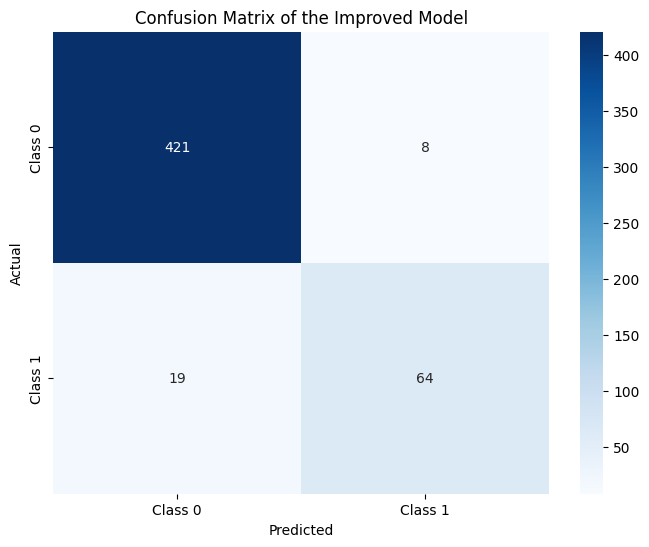

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Get predictions for the test set
y_pred_improved = best_rf_model.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_improved)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of the Improved Model')
plt.show()

**Note**: For the same reason as above, since the model randomly distributes 0 and 1 to depression and non-depression, I can't be sure which is which. Therefore, consider the ones around the number 421 to be non-depression and the ones around 64 to be depression.

**Overall Interpretation**

>The model seems to be doing quite well in correctly identifying cases of "Non Depression" as it has a relatively high number of true positives (421). However, it does have some errors:
>
>There are 19 false positives, which indicates that the model sometimes wrongly classifies people as having depression when they actually don't.
>
>There are also 9 false negatives, meaning that there are a few cases where people who do not have depression were incorrectly classified as having it.
>Compared to "non-depression," the model appears to perform worse at identifying depression cases, likely due to the smaller number of depression cases in the dataset.

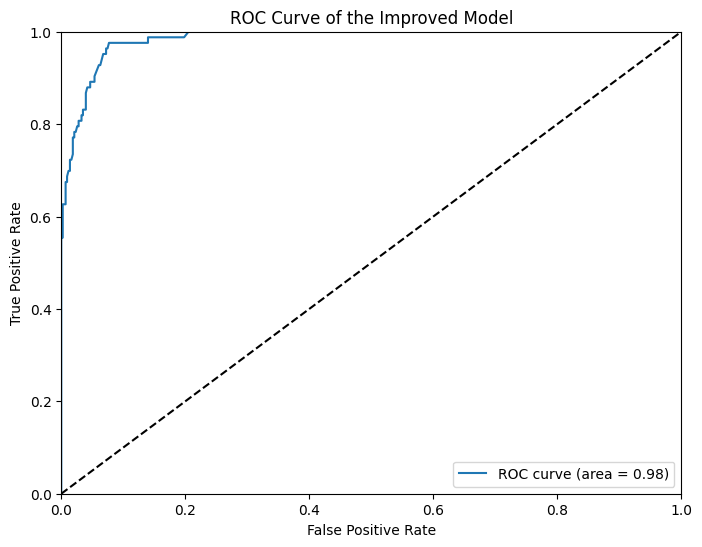

In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# Get predicted probabilities for the positive class
y_proba_improved = best_rf_model.predict_proba(X_test)[:, 1]

# Calculate the false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba_improved)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of the Improved Model')
plt.legend(loc="lower right")
plt.show()

**Overall Interpretation**

 The AUC(Area below ROC curve) close to 1 suggests excellent discriminatory ability of the model between the two classes (depression and non-depression).

### Final Accuracy

>Final accuracy of our best model is 0.947265625

##Alternative:


In [ ]:
from sklearn.cluster import KMeans

# Select the features for clustering (assuming the same features as before)
features = ['Age', 'Job Satisfaction', 'Work Pressure', 'Study Satisfaction',
            'Academic Pressure', 'Work/Study Hours', 'Financial Stress',
            'Student or Not', 'Have you ever had suicidal thoughts ?',
            'Dietary Habits']
X = df[features]

# Initialize and fit the K-Means clustering model (let's assume we choose 3 clusters for illustration purposes)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Get the cluster labels assigned to each data point
cluster_labels = kmeans.labels_

**What we want to understand through the clustering, and our observations**

>By using clustering for this unsupervised learning task, we wanted to understand the natural groupings of individuals in our dataset and understand the characteristics that define these subgroups.

In [ ]:
import pandas as pd
# Create a new DataFrame with the cluster labels
df_clustered = pd.DataFrame({'Cluster': cluster_labels})
cluster_sizes = df_clustered['Cluster'].value_counts()
print(cluster_sizes)

Cluster
1    901
0    829
2    826
Name: count, dtype: int64


In [ ]:
for cluster in range(3):  # Assuming 3 clusters
    cluster_data = df[cluster_labels == cluster]
    print(f"Cluster {cluster} feature means:")
    print(cluster_data[features].mean())

Cluster 0 feature means:
Age                                      24.697226
Job Satisfaction                          3.059279
Work Pressure                             3.028850
Study Satisfaction                        3.065071
Academic Pressure                         3.000822
Work/Study Hours                          6.069964
Financial Stress                          2.949337
Student or Not                            0.490953
Have you ever had suicidal thoughts ?     0.492159
Dietary Habits                            1.020507
dtype: float64
Cluster 1 feature means:
Age                                      52.779134
Job Satisfaction                          2.976693
Work Pressure                             3.028857
Study Satisfaction                        3.075697
Academic Pressure                         3.003984
Work/Study Hours                          5.891232
Financial Stress                          3.024417
Student or Not                            0.000000
Have you ever had

### K-NN

The clustering groups the data by features, and the target is never used. Therefore, we decided to use K-NN instead of K-means to see how unsupervised learning performs in identifying depression.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Define the features and target variable
features = ['Age', 'Job Satisfaction', 'Work Pressure', 'Study Satisfaction',
            'Academic Pressure', 'Work/Study Hours', 'Financial Stress',
            'Student or Not', 'Have you ever had suicidal thoughts ?',
            'Dietary Habits']
target = 'Target'  # Replace with the actual name of your target column

# Split the data into training and testing sets
X = df[features]
y = df['Depression']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and fit the k-NN classifier (k=3 is chosen for illustration purposes)
k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Example: Analyze predictions for a specific data point
example_data = X_test.iloc[0:1]  # Replace with specific data if needed
predicted_cluster = knn.predict(example_data)
print(f"Predicted cluster for the example data: {predicted_cluster}")

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       647
           1       0.73      0.66      0.69       120

    accuracy                           0.91       767
   macro avg       0.83      0.81      0.82       767
weighted avg       0.91      0.91      0.91       767

Accuracy: 0.9087353324641461
Predicted cluster for the example data: [0]


By looking at the accuracy, **Our improved model is better!**

## Permutation_Importance
At this point, we realize that the model above did not fully achieve the goal of this project, which is to identify the key factors that affect depression. So, as Professor Fernando recommended, we used Permutation Importance to identify the key features that influence the predictions in the model which will provide useful insights into the importance of each feature.


                                 Feature  Importance       Std
0                                    Age    0.105085  0.005023
8  Have you ever had suicidal thoughts ?    0.065319  0.004963
4                      Academic Pressure    0.033768  0.002637
6                       Financial Stress    0.022034  0.004302
2                          Work Pressure    0.019426  0.004223
5                       Work/Study Hours    0.017862  0.003870
1                       Job Satisfaction    0.017080  0.003662
3                     Study Satisfaction    0.014211  0.001792
9                         Dietary Habits    0.007953  0.000913
7                         Student or Not    0.003129  0.001769


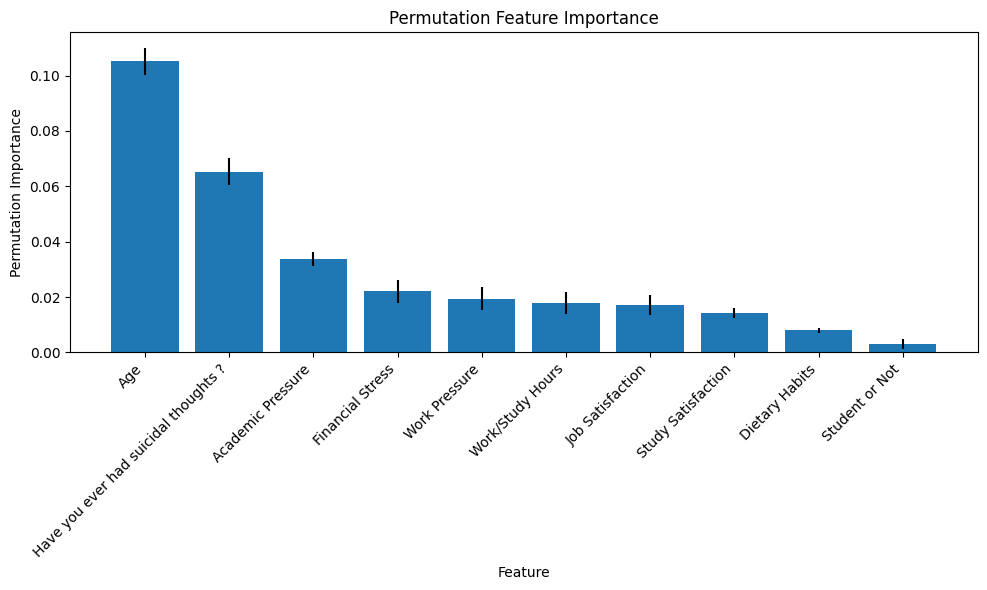

In [ ]:
# prompt: do permutation feature importance analysis on this model

from sklearn.inspection import permutation_importance

# Calculate permutation feature importance
result = permutation_importance(best_rf_model, X_test, y_test, n_repeats=10, random_state=42)

# Get feature importances
importances = result.importances_mean
std = result.importances_std

# Create a DataFrame for easier visualization
importance_df = pd.DataFrame({'Feature': X_test.columns, 'Importance': importances, 'Std': std})

# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importances
print(importance_df)

# You can visualize the importances using a bar plot (optional)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Importance'], yerr=importance_df['Std'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Permutation Importance')
plt.title('Permutation Feature Importance')
plt.tight_layout()
plt.show()

##Findings



**Findings**:
> The Exploratory Data Analysis shows that overall, students exhibit a higher rate of depression compared to non-students. Most features have a greater impact on students than on non-students. However, age appears to influence non-students more significantly, with little impact on students. As age increases, the depression rate decreases. From the permutation feature importance plot above, we can see that age is the most important feature among all the features in the dataset, followed by suicidal thoughts and academic pressure. The importance of age is almost twice as high as that of suicidal thoughts, which is the second most important feature.
>
>Interestingly, individuals with a K-12 education (either current or completed) show the largest population and the highest rate of depression, with almost half (46%) of this population experiencing depression. Most of the K-12 educated population are students, and as mentioned above, the analysis shows that students exhibit a higher rate of depression compared to non-students. This might suggest that being a student is a key factor, but it turns out that it is the least important feature in the predictive model. Looking at the permutation feature importance, we find that it is not being a student that has a strong correlation with depression, but rather academic pressure, which is the key factor explaining why more students experience depression than non-students.
>
>  Though this may not be the proper way to phrase it, it is interesting to see that age is more important than suicidal thoughts in contributing to depression. If I had to guess why, it might be that suicidal thoughts is not the cause of depression; rather, it is depression that leads to suicidal thoughts.
>
>Thus as an conclution to answer the question we propose at the begining, the key factor contribbut the most to predictiong depression is age, then susictial thought, acdemic pressure, diniaical stress, and work pressure imapct.
>
>*PS: It is a good sign that academic pressure is less important than suicidal thoughts, meaning that academic pressure is not as severe a factor in depression.*



**Results Summary**:

>The overall goal of identifying key factors associated with an increased risk of depression has been successfully achieved, particularly in the Permutation_Importance section, where key factors such as age, suicidal thoughts, academic pressure, work pressure, and financial pressure
were highlighted.
>
>In terms of using business context, we recommend applying the model in the mental health field, particularly for psychiatrists and psychologists, with a focus on students. Since age is a major factor contributing to depression, there will be a higher rate of depression among younger individuals. By using this model, it would provide useful insights into whether a patient is likely to have depression.

**Limitations**:
*   While age is identified as the most important feature contributing to depression in the model, we must recognize the limitations of age as a factor. Although age appears influential, for students, age does not show a clear trend in relation to depression. Therefore, we need to consider what exactly is happening here. When examining depression in a historical context, we can see that it is not necessarily age itself that impacts depression, but rather generational differences. This helps explain why age is not a significant factor among students; focusing solely on age may cause us to miss the deeper influence of generational differences on depression.

*   A limitation of the model is the exclusion of the city of residency as a feature due to a lack of related data. City, environment, and cultural differences are strong factors influencing depression, as individuals in different locations may face unique social, economic, and environmental stressors.

*  Another limitation of the model is that it shows correlation rather than causation. Therefore, with the model above, we can't definitively claim that any of the features in the data set, even those shows a strong correlation, are the cause of depression due to this limitation.







**Social/Ethical Considerations**
1. **Privacy and Confidentiality**

* Working with sensitive mental health data requires strict adherence to regulations such as GDPR and HIPAA to ensure data security. Proper measures must be taken to prevent unauthorized access or misuse of personal information.
2. **Bias and Fairness**

* The model may inadvertently perpetuate biases present in the training data, leading to unfair predictions for certain demographic groups (e.g., based on age, gender, or socioeconomic status). To mitigate this, the model must be thoroughly tested and validated across diverse populations to ensure equity.
3. **Interpretability and Accountability**

* In clinical settings, mental health professionals need clear and understandable explanations for the model’s predictions. Ensuring interpretability builds trust and facilitates the integration of the model into diagnostic and treatment processes.

**Future Directions**
1. **Incorporating Additional Factors**

* Future iterations should include more comprehensive data, such as city of residency, cultural background, profession, and access to mental health resources. These additional features will help the model better reflect the complexities of depression risk.
2. **Identifying Underlying Causes**

* Instead of relying on surface-level factors (e.g., being a student), the analysis should focus on identifying the root causes of depression. For example, academic pressure, not student status itself, was found to be a significant contributor. This deeper exploration of predictive features will yield more meaningful insights.
3. **Enhancing Model Robustness**

* Incorporating additional data and refining the model’s focus will improve its robustness and practical applicability, enabling it to serve as a more effective tool in addressing mental health challenges.
